<a href="https://colab.research.google.com/github/drfperez/openair/blob/main/GraficosDIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import base64
import requests
import zlib
from google.colab import files
from IPython.display import HTML, display

CODIGO_MERMAID = """
%%{init: {
  'theme': 'base',
  'themeVariables': {
    'fontFamily': 'sans-serif',
    'lineColor': '#4a4a4a'
  },
  'flowchart': {
    'nodeSpacing': 50,
    'rankSpacing': 40
  }
}}%%
graph TD
    A["<b>1. ENTRADA: CSV GENCAT ORIGINAL</b><br>─────────────<br><code>| Fecha | Estación | H01 | H02 | ... | H24 |</code><br>Datos crudos, múltiples columnas de horas<br><i>(un registro por día-contaminante)</i>"]
    --> B["<b>2. PROCESO DE TRANSFORMACIÓN</b><br>─────────────<br>Aplanado de horas, unificación de fecha y<br>hora en 'date', y renombrado de columnas."]
    --> C["<b>3. SALIDA: CSV OPENAIR (WIDE FORMAT)</b><br>─────────────<br><code>| date | estación | no2 | o3 | pm10 | ...</code><br>Una fila por sello temporal único ('date'),<br>columnas por contaminante. <i>(Listo para openair)</i>"]

    classDef paso1 fill:#dbeafe,stroke:#1e40af,stroke-width:2px,color:#1e293b;
    classDef paso2 fill:#dcfce7,stroke:#166534,stroke-width:2px,color:#1e293b;
    classDef paso3 fill:#f3e8ff,stroke:#6b21a8,stroke-width:2px,color:#1e293b;

    class A paso1;
    class B paso2;
    class C paso3;
"""

# Renderizar en pantalla
display(HTML(f"""
<div style="background-color: #ffffff; padding: 20px; display: inline-block;">
    <div class="mermaid">
    {CODIGO_MERMAID}
    </div>
</div>
<script src="https://cdn.jsdelivr.net/npm/mermaid/dist/mermaid.min.js"></script>
<script>mermaid.initialize({{startOnLoad:true}});</script>
"""))

# Generar PNG 300 DPI y descargar
compressed = zlib.compress(CODIGO_MERMAID.encode('utf-8'), 9)
encoded_kroki = base64.urlsafe_b64encode(compressed).decode('utf-8')
url_kroki = f"https://kroki.io/mermaid/png/{encoded_kroki}"

res = requests.get(url_kroki)
if res.status_code == 200:
    nombre_archivo = "transformacion_gencat_openair.png"
    with open(nombre_archivo, "wb") as f:
        f.write(res.content)
    files.download(nombre_archivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

in label of node nodo1
in label of node nodo2
in label of node nodo3
in label of node nodo1
in label of node nodo2
in label of node nodo3


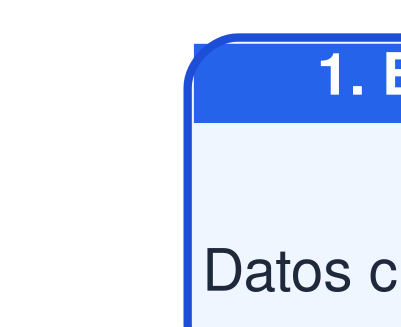

✅ Descargando archivo PNG a 300 DPI...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import graphviz
from google.colab import files
from IPython.display import display

# 1. Definición del código Graphviz (DOT)
dot_code = """
digraph G {
    graph [rankdir=TB, nodesep=0.6, ranksep=0.5, bgcolor="white", dpi=300];
    node [shape=plaintext, fontname="Helvetica, Arial, sans-serif"];
    edge [color="#64748B", penwidth=2, arrowsize=1.2];

    nodo1 [label=<<TABLE BORDER="2" CELLBORDER="0" CELLSPACING="0" COLOR="#1D4ED8" BGCOLOR="#EFF6FF" STYLE="ROUNDED">
        <TR><TD BGCOLOR="#2563EB" PAD="8"><FONT COLOR="white"><B>1. ENTRADA: CSV GENCAT ORIGINAL</B></FONT></TD></TR>
        <TR><TD PAD="12"><FONT COLOR="#1E293B">
            <B>| Fecha | Estación | H01 | H02 | ... | H24 |</B><BR/><BR/>
            Datos crudos, múltiples columnas de horas<BR/>
            <I>(un registro por día-contaminante)</I>
        </FONT></TD></TR>
    </TABLE>>];

    nodo2 [label=<<TABLE BORDER="2" CELLBORDER="0" CELLSPACING="0" COLOR="#15803D" BGCOLOR="#F0FDF4" STYLE="ROUNDED">
        <TR><TD BGCOLOR="#16A34A" PAD="8"><FONT COLOR="white"><B>2. PROCESO DE TRANSFORMACIÓN</B></FONT></TD></TR>
        <TR><TD PAD="12"><FONT COLOR="#1E293B">
            Aplanado de horas, unificación de fecha y<BR/>
            hora en 'date', y renombrado de columnas.
        </FONT></TD></TR>
    </TABLE>>];

    nodo3 [label=<<TABLE BORDER="2" CELLBORDER="0" CELLSPACING="0" COLOR="#7E22CE" BGCOLOR="#FAF5FF" STYLE="ROUNDED">
        <TR><TD BGCOLOR="#9333EA" PAD="8"><FONT COLOR="white"><B>3. SALIDA: CSV OPENAIR (WIDE FORMAT)</B></FONT></TD></TR>
        <TR><TD PAD="12"><FONT COLOR="#1E293B">
            <B>| date | estación | no2 | o3 | pm10 | ...</B><BR/><BR/>
            Una fila por sello temporal único ('date'),<BR/>
            columnas por contaminante. <I>(Listo para openair)</I>
        </FONT></TD></TR>
    </TABLE>>];

    nodo1 -> nodo2 -> nodo3;
}
"""

# 2. Compilación y renderizado con la librería nativa de Graphviz
src = graphviz.Source(dot_code)

# Guardar la imagen en alta resolución (PNG)
nombre_archivo = "transformacion_gencat_graphviz_300dpi"
src.format = 'png'
src.render(filename=nombre_archivo, cleanup=True)

# 3. Mostrar en pantalla y descargar el archivo de forma automática
display(src)
print("✅ Descargando archivo PNG a 300 DPI...")
files.download(f"{nombre_archivo}.png")